In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import fitz
from picconfig import temppath, outputpath

def pdf_to_np(file_path):
    image_arrays = []
    pdf_document = fitz.open(file_path)

    for page_num in range(pdf_document.page_count):
        page = pdf_document.load_page(page_num)
        zoom_matrix = fitz.Matrix(3.0, 3.0)
        pix = page.get_pixmap(matrix=zoom_matrix)
        channels = pix.n
        image_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape((pix.height, pix.width, channels))
        image_arrays.append(image_array)

    return image_arrays

In [2]:
img1 = pdf_to_np(f"{temppath}t-SNE Plot.pdf")[0]
img2 = plt.imread(f"{temppath}Network1.png")
img3 = plt.imread(f"{temppath}Network2.png")
img5 = pdf_to_np(f"{temppath}human.pdf")[0]

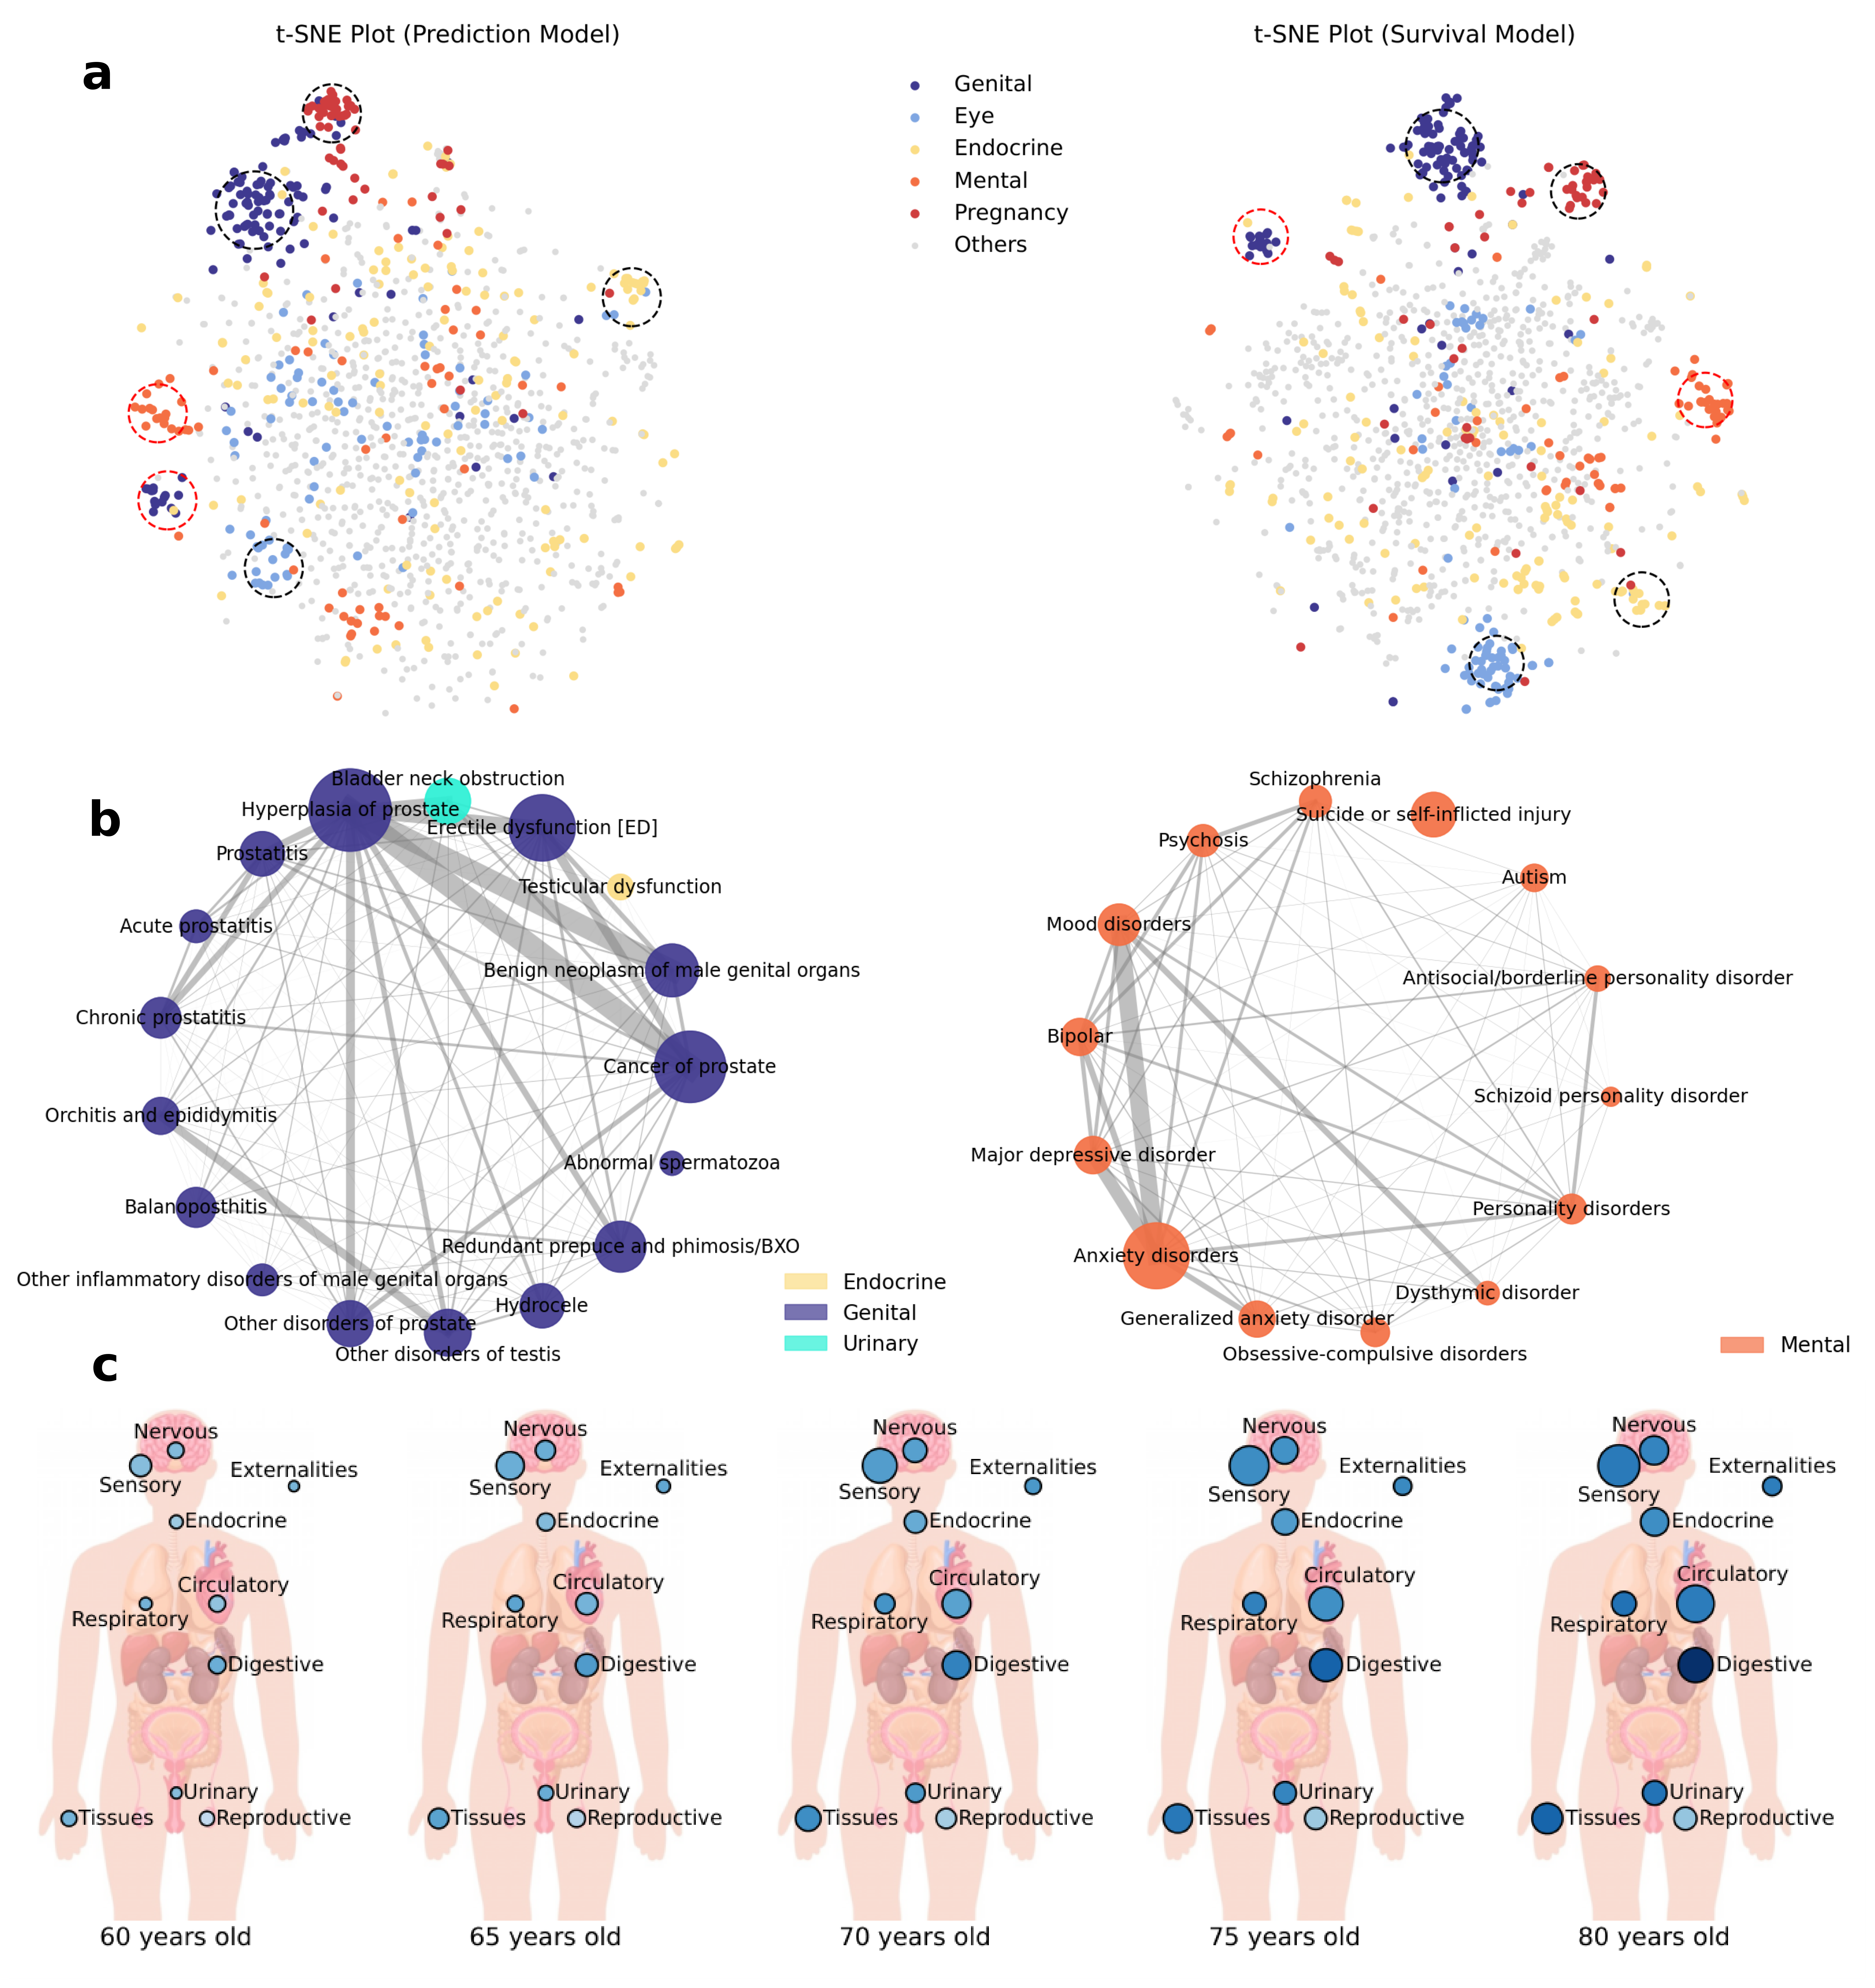

In [3]:
fig = plt.figure(figsize=(28, 36), dpi=300)
gs0 = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1.1,1,1], wspace=0, hspace=-0.4, width_ratios=[img2.shape[1]*img3.shape[0],img2.shape[0]*img3.shape[1]])
ax1 = fig.add_subplot(gs0[0, :])
ax1.imshow(img1)
ax1.axis('off')
ax1.text(100,110,"a", fontsize=40, fontweight=600)
ax2 = fig.add_subplot(gs0[1, 0])
ax2.imshow(img2)
ax2.axis('off')
ax2.text(100,110,"b", fontsize=40, fontweight=600)
ax3 = fig.add_subplot(gs0[1, 1])
ax3.imshow(img3)
ax3.axis('off')
# ax3.text(200,35,"c", fontsize=40, fontweight=600)
ax5 = fig.add_subplot(gs0[2, :])
ax5.imshow(img5)
ax5.axis('off')
ax5.text(60,0,"c", fontsize=40, fontweight=600)
plt.savefig(f"{outputpath}fig5_multimorbidity.pdf",format="pdf",bbox_inches="tight")
plt.show()